In [4]:
import os
import cv2
import tqdm
import sys

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

from datetime import datetime
from pathlib import Path
import xarray as xr

In [2]:
%load_ext autoreload
%autoreload 2

In [30]:
import sys

root_dir = Path(os.getcwd()).parent.parent.parent

# Add the root directory to Python path
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from models.architectures.Unet import convbatchrelu, convdown, downsample, convup, upsample, Unet
from src.seed import set_seed, seed_worker, set_device
from src.data_pipeline.loaders.data_loaders import get_data_loaders
from src.data_pipeline.sourcing.downloaders.download_data import download_data
from src.data_pipeline.preprocessing.preprocess import normalize99

C:\Users\atle_\AppData\Roaming\Python\Python312\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [31]:
SEED = 2021
set_seed(seed=SEED)
DEVICE = set_device()

Random seed 2021 has been set.


### Load Dataset

In [ ]:
data_dir = root_dir / 'data' / 'ca_imaging'

dataset = xr.load_dataset(data_dir / 'cells_data_all.nc')
dataset

<xarray.Dataset> Size: 178MB
Dimensions:        (image_nr: 91, staining: 2, height: 383, width: 512)
Coordinates:
  * image_nr       (image_nr) int64 728B 0 1 2 3 4 5 6 ... 84 85 86 87 88 89 90
  * staining       (staining) <U9 72B 'cytoplasm' 'nuclear'
Dimensions without coordinates: height, width
Data variables:
    ca_image_data  (image_nr, staining, height, width) uint8 36MB 0 0 0 ... 8 8
    cell_labels    (image_nr, height, width) int64 143MB 0 0 0 0 0 ... 0 0 0 0 0

Extract images and labels from dataset

In [51]:
images = dataset['ca_image_data'].values
labels = dataset['cell_labels'].values

In [52]:
images = np.array([normalize99(img) for img in images])
images

array([[[[-0.03305785, -0.03305785, -0.03305785, ...,  0.2644628 ,
           0.338843  ,  0.3305785 ],
         [-0.00826446, -0.00826446, -0.00826446, ...,  0.18181819,
           0.32231405,  0.3305785 ],
         [-0.00826446, -0.00826446,  0.        , ...,  0.10743801,
           0.2892562 ,  0.3305785 ],
         ...,
         [ 0.        ,  0.        ,  0.        , ...,  0.00826446,
           0.01652892,  0.03305785],
         [ 0.        ,  0.        ,  0.        , ...,  0.00826446,
           0.01652892,  0.02479339],
         [ 0.        ,  0.        ,  0.        , ...,  0.00826446,
           0.01652892,  0.01652892]],

        [[-0.01652892, -0.02479339, -0.02479339, ..., -0.00826446,
           0.        , -0.00826446],
         [ 0.01652892,  0.02479339,  0.02479339, ...,  0.01652892,
           0.01652892,  0.02479339],
         [ 0.02479339,  0.03305785,  0.02479339, ...,  0.02479339,
           0.02479339,  0.02479339],
         ...,
         [ 0.04132231,  0.04132231

### Define model

In [65]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(224*224, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
        )
    
    def forward(self, x):
        return self.layers(x)
    
    def predict(self, x):
        output = self.forward(x)
        return torch.argmax(output, dim=1)

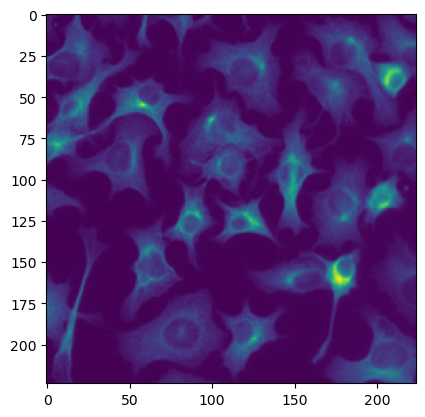

In [66]:
plt.imshow(images[0,0])

In [67]:
import cv2
import numpy as np

# Your image dimensions
img = images  # shape: (8, 2, 383, 512)
nimages, nchan, height, width = img.shape  # 8, 2, 383, 512
xy = (224, 224)

# Define source points (corners of center crop in original image)
crop_h, crop_w = xy[0], xy[1]
top = (height - crop_h) // 2
left = (width - crop_w) // 2

# Source points: top-left, top-right, bottom-left of crop region
pts1 = np.float32([
    [left, top],           # top-left
    [left + crop_w, top],  # top-right
    [left, top + crop_h]   # bottom-left
])

# Destination points: map to full output image
pts2 = np.float32([
    [0, 0],           # top-left
    [crop_w, 0],      # top-right
    [0, crop_h]       # bottom-left
])

# Get affine transformation matrix
M = cv2.getAffineTransform(pts1, pts2)

# Apply transformation
imgi = np.zeros((nimages, nchan, xy[0], xy[1]), dtype=img.dtype)
lbli = np.zeros((nimages, 1, xy[0], xy[1]), dtype=img.dtype)

for n in range(nimages):
    for k in range(nchan):
        I = cv2.warpAffine(img[n, k], M, (xy[1], xy[0]), flags=cv2.INTER_LINEAR)
        imgi[n, k] = I

    
    # ** nearest neighbor interpolation **
    # may need to change for float labels
    #lbli[n] = cv2.warpAffine(labels[], M, (xy[1], xy[0]),
    #                            flags=cv2.INTER_NEAREST)

TypeError: Cannot interpret 'torch.float32' as a data type

In [68]:
images = torch.tensor(imgi)
labels = torch.tensor(lbli)

In [69]:
images.shape

torch.Size([91, 2, 224, 224])

In [ ]:
model = SimpleNet()

model(images[0,0].flatten())

tensor(0)

In [62]:
kernel_size = 3
nbase = [2, 32, 64, 128, 256]  # number of channels per layer
nout = 2  # number of outputs

model = Unet(nbase, nout, kernel_size)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device);

model(images[:8]).shape

torch.Size([8, 2, 224, 224])

In [ ]:
model = SimpleNet()

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

loss_function = nn.CrossEntropyLoss()

optimizer.zero_grad()

model.forward()